## Step 2: Dataset Loading & Exploratory Data Analysis

### 2.1  Load & Understand the Dataset

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('dataset/house_dataset.csv')

In [3]:
print(df.shape)

(1460, 81)


#### Identify: 
* how many numerical columns
* how many categorical columns 
* how many columns have missing values

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
num_cols = df.select_dtypes(exclude='object').columns
cat_cols = df.select_dtypes(include='object').columns

print(f'Total Numerical columns in this dataset: \n{len(num_cols)}')
print('='*45)
print(f'Total Categorical columns in this dataset: \n{len(cat_cols)}')
print('='*45)
print('Total columns with Missing Values:')
print((df.isna().sum() > 0).values.sum())

Total Numerical columns in this dataset: 
38
Total Categorical columns in this dataset: 
43
Total columns with Missing Values:
19


#### Plot a histogram of the target variable SalePrice

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

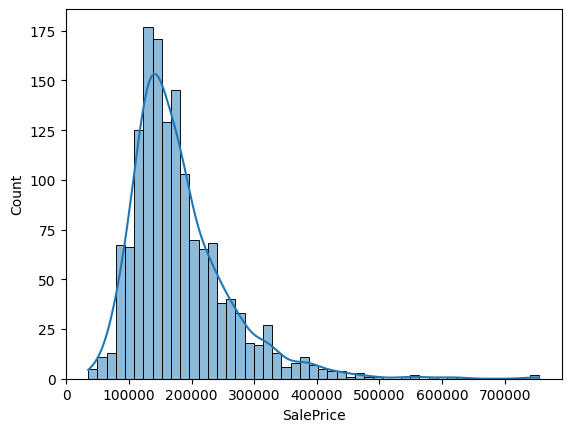

In [7]:
sns.histplot(df['SalePrice'], kde=True)
plt.show()

This data is not normally distributed so we will apply log1p transformation.

#### Apply log1p transformation and re-plot.

In [8]:
df['SalePrice'] = np.log1p(df['SalePrice'])

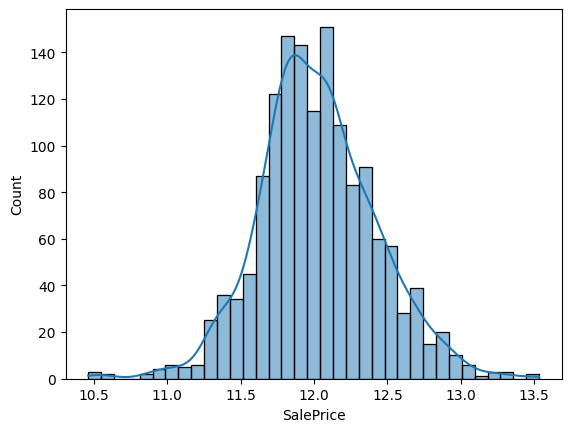

In [9]:
sns.histplot(df['SalePrice'], kde=True)
plt.show()

### 2.2  Univariate Analysis

#### Identify the top 5 most skewed columns

In [10]:
skewness = df.select_dtypes(include='number').skew().sort_values(ascending=False)
print(skewness.head(5))

MiscVal         24.476794
PoolArea        14.828374
LotArea         12.207688
3SsnPorch       10.304342
LowQualFinSF     9.011341
dtype: float64


#### Plot countplot for high-impact categorical column

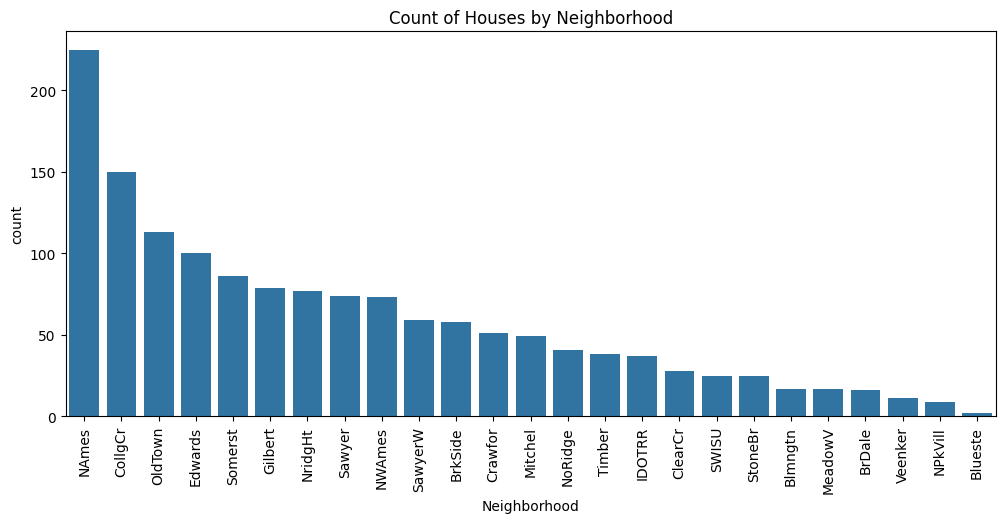

In [11]:
plt.figure(figsize=(12,5))
sns.countplot(x='Neighborhood', data=df, order=df['Neighborhood'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Count of Houses by Neighborhood")
plt.show()

### 2.3  Bivariate Analysis

#### Plot a heatmap of the top 15 features most correlated with SalePrice

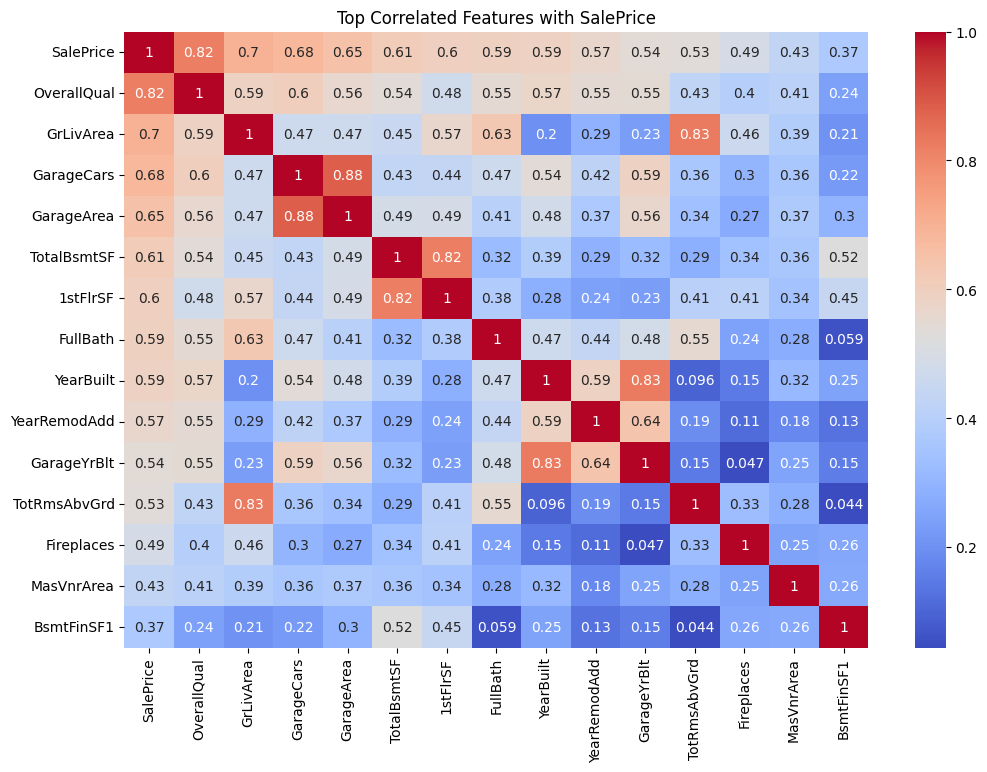

In [12]:
#  Correlation Heatmap (Top features)
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

# Select top 15 correlated with SalePrice
top_corr = corr['SalePrice'].sort_values(ascending=False).head(15)

sns.heatmap(df[top_corr.index].corr(), annot=True, cmap="coolwarm")
plt.title("Top Correlated Features with SalePrice")
plt.show()

#### Scatter plot

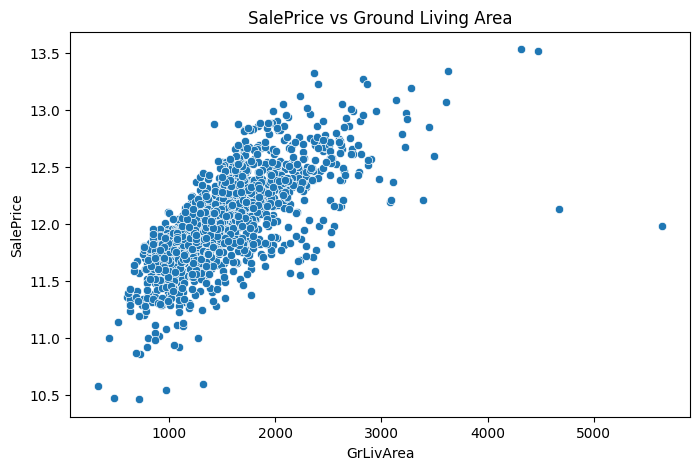

In [13]:
# SalePrice vs Living Area
plt.figure(figsize=(8,5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title("SalePrice vs Ground Living Area")
plt.show()

## Step 3: Data Preprocessing & Feature Engineering

#### Report all columns with missing values and their missing %.

In [14]:
missing_percentage = ((df.isna().sum() / len(df)) * 100).round(2)
print(missing_percentage[missing_percentage > 0])

LotFrontage     17.74
Alley           93.77
MasVnrType      59.73
MasVnrArea       0.55
BsmtQual         2.53
BsmtCond         2.53
BsmtExposure     2.60
BsmtFinType1     2.53
BsmtFinType2     2.60
Electrical       0.07
FireplaceQu     47.26
GarageType       5.55
GarageYrBlt      5.55
GarageFinish     5.55
GarageQual       5.55
GarageCond       5.55
PoolQC          99.52
Fence           80.75
MiscFeature     96.30
dtype: float64


#### Drop columns with >80% missing values

In [15]:
df.drop(missing_percentage[missing_percentage > 80].index,axis=1,inplace=True)

#### For categorical columns where NaN means 'None' — fill with 'None'.

In [16]:
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna("None")

#### For numerical columns where NaN means 0 — fill with 0.

In [17]:
zero_fill_cols = [
    'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 
    'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea'
]
df[zero_fill_cols] = df[zero_fill_cols].fillna(0)

#### For remaining numerical columns — fill with median

In [18]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

In [19]:
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)

In [20]:
df['GarageYrBlt'] = np.where(
    df['HasGarage'] == 1, 
    df['YearBuilt'],   # if they have a garage, set to YearBuilt
    0                  # else, set to 0
)

### 3.2  Outlier Removal

In [21]:
df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < np.log1p(300000))].index)

#### Briefly explain why keeping these outliers would harm a linear model.


* Pulls the Regression Line: Because linear regression minimizes squared errors, it penalizes large distances heavily. The model will literally tilt or shift the entire line of best fit just to get closer to a few extreme outliers, ruining the predictions for the rest of your data.
* Skews Performance Metrics: Outliers artificially inflate error metrics like MSE (Mean Squared Error) and distort $R^2$, making it incredibly difficult to gauge the model's true accuracy.
* Breaks Statistical Assumptions: They destroy the required assumptions of homoscedasticity (constant variance) and normally distributed residuals, which completely invalidates your $p$-values, confidence intervals, and hypothesis tests.

### 3.3  Feature Engineering

#### Create TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF (total usable area).


In [22]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

#### Create HouseAge = YrSold - YearBuilt.

In [23]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

#### Create RemodAge = YrSold - YearRemodAdd

In [24]:
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

#### Create HasGarage = 1 if GarageArea > 0 else 0.

In [25]:
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)

#### Create HasPool = 1 if PoolArea > 0 else 0

In [26]:
df['HasPool'] = (df['PoolArea'] > 0).astype(int)

### 3.4  Encoding & Scaling

In [27]:
# Apply Ordinal Encoding to quality/condition columns

# Define mapping
qual_map = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

# Columns to encode
qual_cols = ['ExterQual', 'KitchenQual', 'BsmtQual', 'FireplaceQu']

# Apply mapping
for col in qual_cols:
    df[col] = df[col].map(qual_map)

In [28]:
# Separate target
y = df['SalePrice']
X = df.drop(['SalePrice','Id'], axis=1)

# Numerical & categorical columns
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Low & high cardinality categoricals
low_card_cat = [col for col in cat_cols if X[col].nunique() <= 10]
high_card_cat = [col for col in cat_cols if X[col].nunique() > 10]

In [29]:
# Apply log1p transformation to skewed numerical features

# Find skewed features
skewness = X[num_cols].skew()
skewed_cols = skewness[skewness > 0.75].index

# Apply log1p
for col in skewed_cols:
    X[col] = np.log1p(X[col])

In [30]:
# label-encode to remaining columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for i in high_card_cat:
    X[i] = le.fit_transform(X[i])

#### Use ColumnTransformer + Pipeline to chain all transformations cleanly.

In [31]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [32]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), low_card_cat)
    ],
    remainder='passthrough'  # keeps Neighborhood (label encoded)
)

### 3.5  Train-Test Split

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
# Print shapes of X_train, X_test, y_train, y_test
print(f'X Train: {X_train.shape}')
print(f'X Test: {X_test.shape}')
print(f'y Train: {y_train.shape}')
print(f'y Test: {y_test.shape}')

X Train: (1166, 80)
X Test: (292, 80)
y Train: (1166,)
y Test: (292,)


## Step 4: Regression Models — Linear, Ridge & Lasso

In [36]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV

In [37]:
# Train a LinearRegression model. Predict on X_test.

# Linear 
pipe_lr = Pipeline([
('preprocessor', preprocessor),
('model', LinearRegression())
])

pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_test)

# Ridge

pipe_ridge = Pipeline([
('preprocessor', preprocessor),
('model', RidgeCV(alphas=[0.01,0.1,1,10,100]))
])

pipe_ridge.fit(X_train, y_train)
pred_ridge = pipe_ridge.predict(X_test)

# Lasso

pipe_lasso = Pipeline([
('preprocessor', preprocessor),
('model', LassoCV(alphas=[0.0001,0.001,0.01,0.1,1], max_iter=10000))
])

pipe_lasso.fit(X_train, y_train)
pred_lasso = pipe_lasso.predict(X_test)

C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.346e-02, tolerance: 1.414e-02
  model = cd_fast.enet_coordinate_descent_gram(


## Step 5: Advanced Models — Random Forest & XGBoost Regressor

In [38]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [39]:
# Random Forest

pipe_rf = Pipeline([
('preprocessor', preprocessor),
('model', RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42))
])

pipe_rf.fit(X_train, y_train)
pred_rf = pipe_rf.predict(X_test)

In [40]:
# XGBoost

pipe_xgb = Pipeline([
('preprocessor', preprocessor),
('model', XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8))
])

pipe_xgb.fit(X_train, y_train)
pred_xgb = pipe_xgb.predict(X_test)

#### Model Comparison: Ridge vs Lasso

Ridge Regression performed slightly better than Lasso Regression, with an R² score higher.

Although the difference is very small, Ridge is preferred because:
- Ridge (L2 regularization) reduces coefficient values but does not eliminate features.
- It performs better when most features are relevant, as in this dataset.
- Lasso (L1 regularization) performs feature selection by shrinking some coefficients to zero, which may lead to slight information loss.

Since the dataset contains many useful features (especially after encoding), Ridge was able to capture more information, resulting in slightly better performance.


In [44]:
from sklearn.model_selection import cross_val_score

In [45]:
# Cross-Validation
best_model = pipe_xgb

cv_scores = cross_val_score(best_model, X, y, scoring='r2', cv=5)
cv_scores

array([0.90797623, 0.91233408, 0.89372302, 0.91758274, 0.90891434])

In [46]:
from sklearn.model_selection import GridSearchCV

In [62]:
# Hyperparameter Tuning

param_dist = {
'model__n_estimators': [500,700],
'model__max_depth': [7,10 ],
}

grid_search = GridSearchCV(pipe_rf, param_grid=param_dist, cv=5, n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)

Best Params: {'model__max_depth': 10, 'model__n_estimators': 700}


## Step 6: Model Evaluation & Comparison

In [53]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
import time

In [64]:
results = []

models = {
    "Linear": pipe_lr,
    "Ridge": pipe_ridge,
    "Lasso": pipe_lasso,
    "RandomForest": pipe_rf,
    "XGBoost": pipe_xgb
}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    
    train_time = time.time() - start
    
    y_pred = model.predict(X_test)
    
    # Convert back to original scale
    y_test_exp = np.expm1(y_test)
    y_pred_exp = np.expm1(y_pred)
    
    rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
    mae = mean_absolute_error(y_test_exp, y_pred_exp)
    r2 = r2_score(y_test_exp, y_pred_exp)
    
    # CV RMSE
    cv_rmse = np.sqrt(-cross_val_score(model, X_train, y_train,
                                       scoring='neg_mean_squared_error',
                                       cv=5)).mean()
    
    results.append([name, rmse, mae, r2, cv_rmse, train_time])

comparison_df = pd.DataFrame(results, columns=[
    "Model", "RMSE", "MAE", "R2", "CV_RMSE", "Train_Time_sec"
])

comparison_df.sort_values(by="RMSE", inplace=True)

comparison_df

C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.346e-02, tolerance: 1.414e-02
  model = cd_fast.enet_coordinate_descent_gram(


,Model,RMSE,MAE,R2,CV_RMSE,Train_Time_sec
4,XGBoost,19669.532647,14237.473245,0.929958,0.123891,2.048103
2,Lasso,19944.026217,14650.318764,0.927990,0.117998,0.525071
1,Ridge,20476.483605,14683.612916,0.924094,0.117904,0.126682
0,Linear,22647.352921,15796.825609,0.907146,0.133787,0.134051
3,RandomForest,23004.885007,16260.918322,0.904191,0.138760,5.478058


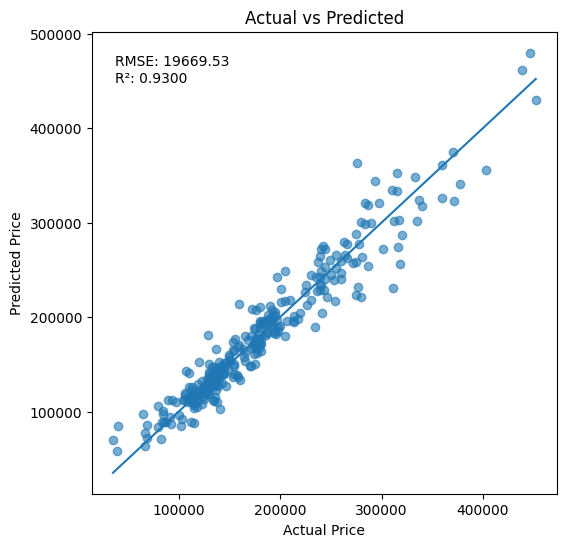

In [65]:
best_model = pipe_xgb

y_pred = best_model.predict(X_test)

y_test_exp = np.expm1(y_test)
y_pred_exp = np.expm1(y_pred)

rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
r2 = r2_score(y_test_exp, y_pred_exp)

plt.figure(figsize=(6,6))
plt.scatter(y_test_exp, y_pred_exp, alpha=0.6)
plt.plot([y_test_exp.min(), y_test_exp.max()],
         [y_test_exp.min(), y_test_exp.max()])

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.text(0.05, 0.95,
         f"RMSE: {rmse:.2f}\nR²: {r2:.4f}",
         transform=plt.gca().transAxes,
         verticalalignment='top')

plt.show()

Among all models, XGBosst Regression performed the best with the lowest RMSE and highest R² score, although the margin compared to Lasso and XGBoost was small.

Ridge is preferred because it effectively handles multicollinearity and retains all features, which is beneficial in a dataset with many encoded variables. While tree-based models like Random Forest and XGBoost can capture non-linear relationships, they are more complex and less interpretable.

From a production standpoint, Ridge offers a strong balance between performance, stability, and interpretability, making it suitable for deployment in real-world pricing systems.

Additionally, its RMSE in absolute price terms is lower, which is critical for business applications like real estate pricing where prediction error directly impacts financial decisions.

## Step 7: Residual Analysis & Model Interpretation

### 7.1  Residual Plots

#### Plot Residuals vs Fitted values for your best model

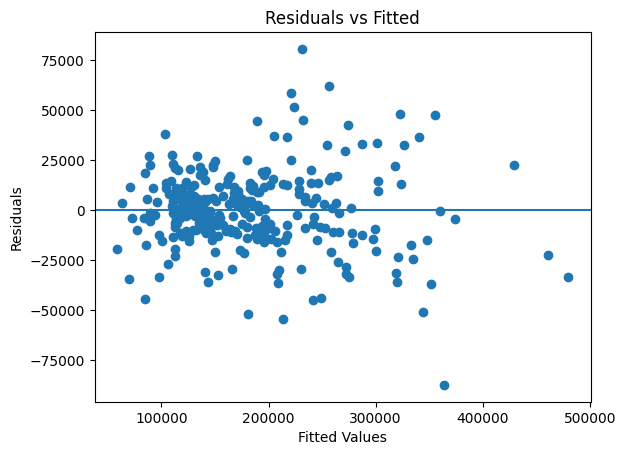

In [66]:
residuals = y_test_exp - y_pred_exp

plt.scatter(y_pred_exp, residuals)
plt.axhline(y=0)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")

plt.show()

#### Plot a histogram of residuals

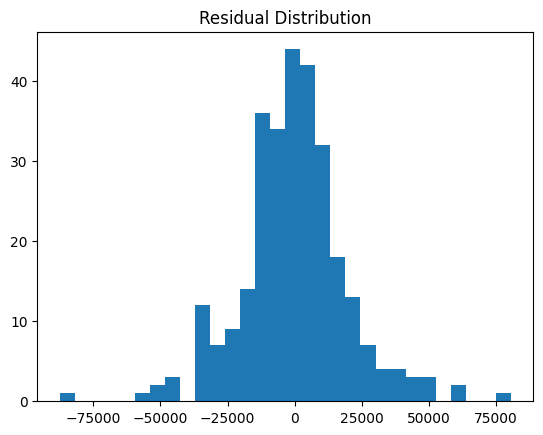

In [67]:
plt.hist(residuals, bins=30)

plt.title("Residual Distribution")
plt.show()

#### Plot a Q-Q plot of residuals

FileNotFoundError: [Errno 2] No such file or directory: 'figure/Q-Q_plot.png'

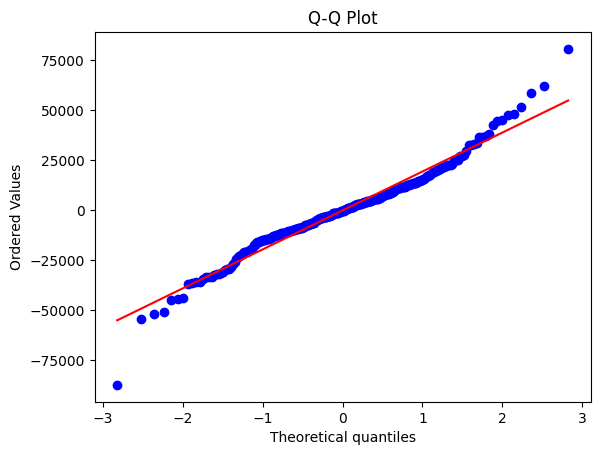

In [75]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.savefig('figure/Q-Q_plot.png',dpi=300)
plt.show()

### 7.2  Business Interpretation

In [73]:
# Get feature importance from XGBoost
importance = pipe_xgb['model'].feature_importances_

feature_names = preprocessor.get_feature_names_out()

feat_imp = pd.Series(importance, index=feature_names)\
            .sort_values(ascending=False)

feat_imp.index = feat_imp.index.str.replace('num__', '')\
                               .str.replace('cat__', '')

# Top 5 features
top5 = feat_imp.head(5)

top5

OverallQual     0.168235
ExterQual       0.135868
TotalSF         0.109394
CentralAir_N    0.056154
CentralAir_Y    0.051232
dtype: float32

### Key Feature Insights (XGBoost Model)

1. OverallQual:
   This is the most influential feature. It represents the overall material and finish quality of the house. Properties with higher quality ratings command significantly higher prices, making it the strongest predictor.

2. ExterQual:
   Exterior quality plays a major role in pricing. Homes with better exterior materials and finishing not only look more appealing but also indicate durability, leading to higher valuations.

3. TotalSF:
   The total square footage of the house strongly impacts price. Larger homes provide more living space and functionality, which directly increases their market value.

4. CentralAir_N:
   The absence of central air conditioning negatively impacts house prices. Buyers consider this a basic amenity, and lack of it reduces property desirability.

5. CentralAir_Y:
   The presence of central air conditioning positively influences price. It reflects better comfort and modern living standards, increasing buyer willingness to pay.

CentralAir was one-hot encoded into two binary variables (Yes/No). The model assigns importance to both, indicating that the presence or absence of air conditioning significantly affects pricing decisions.

Quality-related features (OverallQual, ExterQual) dominate the model, suggesting that construction quality has a greater impact on pricing than size alone. However, TotalSF confirms that space remains a key driver of value.

## Step 8: Pipeline, Deploymen

In [74]:
import joblib

joblib.dump(pipe_xgb, 'house_price_model.pkl')

['house_price_model.pkl']